In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [11]:
df = pd.read_csv('nba_games.csv')
print(len(df))
df = df.dropna()
print(len(df))

26651
26552


In [31]:
'''
There are 30 teams in the leagues. If we give each team their own column, then represent home as 1 and
away as -1 and introduce a bias all the terms should be accounted for. So, we must find all unique team ids
to create X.
'''

from sklearn.model_selection import train_test_split

y = df['PTS_home'] - df['PTS_away']

teams = pd.unique(df['HOME_TEAM_ID'].values.ravel())
team_to_idx = {team: i for i, team in enumerate(teams)}

n = len(df)
X = np.zeros((n, 31))

for idx, (i, row) in enumerate(df.iterrows()):
    X[idx, team_to_idx[row['HOME_TEAM_ID']]] = 1
    X[idx, team_to_idx[row['VISITOR_TEAM_ID']]] = -1
    X[idx, 30] = 1

X = pd.DataFrame(X)
X.columns = teams.tolist() + ['bias']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)
X.head()

,1610612740,1610612762,1610612739,1610612755,1610612737,1610612738,1610612751,1610612752,1610612745,1610612750,...,1610612749,1610612766,1610612741,1610612742,1610612763,1610612753,1610612764,1610612757,1610612744,bias
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,1.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [32]:
rk = np.linalg.matrix_rank(X)
print(f'The rank of our matrix X is {rk}.')

The rank of our matrix X is 30.


In [ ]:
'''
The rank is 30, yet we have 31 columns. This is because we are running into the dummy variable trap.
If a team is home, we know they are not away.
'''

In [33]:
XTX = np.dot(np.transpose(X_train), X_train)
XTXINV = np.linalg.inv(XTX)
ls = np.dot(np.dot(XTXINV, np.transpose(X_train)), y_train)
print(f'Coefficients: {ls}')

Coefficients: [-0.63835692  4.21070151  0.17459661  0.08436584  0.49426064  3.58537455
 -2.02136871 -0.39305157  2.41380349 -0.03863518  5.48069138 -0.67249677
  0.67525713  1.31259906  2.9402285   2.96385597  4.50008255  1.01851165
  1.79024113  0.5752884   6.29199057 -1.04504997 -1.50028729  0.09868649
  3.12365893  1.38530674 -0.02265294 -2.18038863  0.8456683   3.54580366
  2.82382636]


In [ ]:
'''
The bias term would indicate factors other than team skill that affect our games, most obviously, home court
advantage. The positive signedeness indicates that the home team has an advantage.
'''

In [35]:
from sklearn.metrics import root_mean_squared_error, r2_score

y_pred_train = np.dot(X_train, ls)
y_pred_test = np.dot(X_test, ls)

rmse_train = root_mean_squared_error(y_train, y_pred_train)
rmse_test = root_mean_squared_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f'RMSE on training set: {rmse_train:.2f}')
print(f'R^2 on training set: {r2_train:.2f}')
print(f'RMSE on test set: {rmse_test:.2f}')
print(f'R^2 on test set: {r2_test:.2f}')

RMSE on training set: 13.40
R^2 on training set: 0.02
RMSE on test set: 13.29
R^2 on test set: 0.01


In [ ]:
'''
This is a very bad performance. Almost none of the point differential is explained by our team skill variables.
A RMSE of 13 means we predict the point swing wrong by 13 points on average. There is a lot of
variation in basketball, so this should be expected.

In [36]:
team_points = {team: 0 for team in team_to_idx}

for _, row in df.iterrows():
    if row['HOME_TEAM_WINS'] == 1:
        team_points[row['HOME_TEAM_ID']] += 3
    elif row['HOME_TEAM_WINS'] == 0:
        team_points[row['VISITOR_TEAM_ID']] += 3
    else:  # tie
        team_points[row['HOME_TEAM_ID']] += 1
        team_points[row['VISITOR_TEAM_ID']] += 1

team_points_df = pd.DataFrame(list(team_points.items()), columns=['Team', 'Points'])
team_points_df = team_points_df.sort_values('Points', ascending=False)

'\nWe observe a positive correlation. The higher the skill level, the more points a team generally earns.\nIt seems we are able to determine team skill and team skill does have predictive power, but only over the \ncourse of a season. During a single game, variance wins out. \n'

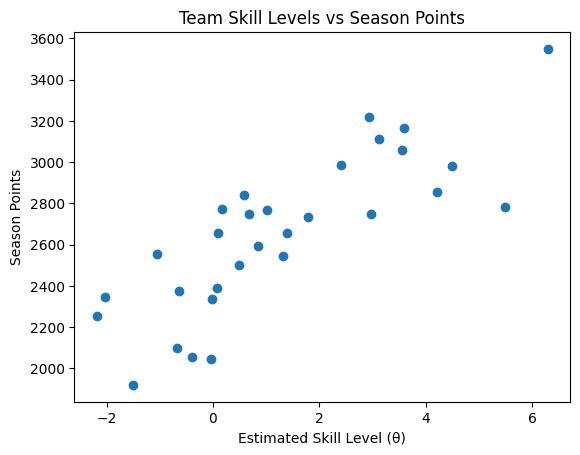

In [40]:
# Get theta values for each team (excluding bias)
team_skills = {team: ls[idx] for team, idx in team_to_idx.items()}

# Align both dicts
teams = list(team_to_idx.keys())
skills = [team_skills[t] for t in teams]
points = [team_points[t] for t in teams]

plt.scatter(skills, points)

plt.xlabel('Estimated Skill Level (θ)')
plt.ylabel('Season Points')
plt.title('Team Skill Levels vs Season Points')

'''
We observe a positive correlation. The higher the skill level, the more points a team generally earns.
It seems we are able to determine team skill and team skill does have predictive power, but only over the
course of a season. During a single game, variance wins out.
'''